In [1]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
id2label = {0: "NEGATIVO", 1: "NEUTRO", 2: "POSITIVO"}
clases = ["NEGATIVO", "NEUTRO", "POSITIVO"]
archivo_entrada = "predecir.csv"

df = pd.read_csv(archivo_entrada, sep='|')
df['texto'] = df['texto'].astype(str).str.strip()
df['sentimiento'] = df['sentimiento'].astype(str).str.strip().str.upper()

In [3]:
def cargar_modelo(ruta):
    tokenizer = AutoTokenizer.from_pretrained(ruta)
    model = AutoModelForSequenceClassification.from_pretrained(ruta).to(device)
    model.eval()
    return tokenizer, model

def clasificar_comentarios(lista_textos, tokenizer, model, batch_size=32):
    predicciones_finales = []
    for i in range(0, len(lista_textos), batch_size):
        batch_textos = lista_textos[i:i+batch_size]
        inputs = tokenizer(batch_textos, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        indices_predichos = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        for idx in indices_predichos:
            predicciones_finales.append(id2label[idx])
    return predicciones_finales

def evaluar_modelo(nombre, ruta_modelo, archivo_salida, archivo_imagen):
    tokenizer, model = cargar_modelo(ruta_modelo)
    df_eval = df.copy()
    df_eval['sentimiento_predicho'] = clasificar_comentarios(df_eval['texto'].tolist(), tokenizer, model)
    df_eval.to_csv(archivo_salida, index=False, sep='|')
    df_eval['correcto'] = df_eval['sentimiento'] == df_eval['sentimiento_predicho']
    aciertos = df_eval['correcto'].sum()
    total = len(df_eval)
    precision = aciertos / total * 100
    print(f"Resultado {nombre}: {aciertos} aciertos de {total} ({precision:.1f}%)")
    matriz = confusion_matrix(df_eval['sentimiento'], df_eval['sentimiento_predicho'], labels=clases)
    plt.figure(figsize=(7, 5))
    sns.set_theme(style="white")
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', xticklabels=clases, yticklabels=clases, cbar=False, annot_kws={"size": 14, "weight": "bold"})
    plt.title(f'Matriz de Confusión {nombre}: Real vs. Predicho', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('Sentimiento Real', fontsize=12, fontweight='bold')
    plt.xlabel('Sentimiento Predicho (IA)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(archivo_imagen, dpi=300, bbox_inches='tight')
    print(f"\nReporte de Métricas {nombre}:")
    print(classification_report(df_eval['sentimiento'], df_eval['sentimiento_predicho'], target_names=clases, zero_division=0))
    plt.show()
    return df_eval

def comparar_modelos(df_a, df_b, nombre_a="Modelo A", nombre_b="Modelo B"):
    total = len(df_a)
    aciertos_a = (df_a['sentimiento'] == df_a['sentimiento_predicho']).sum()
    aciertos_b = (df_b['sentimiento'] == df_b['sentimiento_predicho']).sum()
    precision_a = aciertos_a / total * 100
    precision_b = aciertos_b / total * 100
    mejora_absoluta = precision_b - precision_a
    mejora_relativa = (mejora_absoluta / precision_a * 100) if precision_a > 0 else float('inf')
    print(f"Precisión {nombre_a}: {precision_a:.2f}%")
    print(f"Precisión {nombre_b}: {precision_b:.2f}%")
    print(f"Mejora absoluta: {mejora_absoluta:+.2f} puntos porcentuales")
    print(f"Mejora relativa: {mejora_relativa:+.2f}%")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.set_theme(style="white")
    for ax, df_m, nombre in zip(axes, [df_a, df_b], [nombre_a, nombre_b]):
        matriz = confusion_matrix(df_m['sentimiento'], df_m['sentimiento_predicho'], labels=clases)
        sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', xticklabels=clases, yticklabels=clases, cbar=False, annot_kws={"size": 12, "weight": "bold"}, ax=ax)
        ax.set_title(f'{nombre}\nPrecisión: {((df_m["sentimiento"] == df_m["sentimiento_predicho"]).sum()/total*100):.2f}%', fontsize=12, fontweight='bold')
        ax.set_ylabel('Sentimiento Real', fontsize=10, fontweight='bold')
        ax.set_xlabel('Sentimiento Predicho (IA)', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig('comparacion_modelos.png', dpi=300, bbox_inches='tight')
    plt.show()
    return {
        'precision_a': precision_a,
        'precision_b': precision_b,
        'mejora_absoluta': mejora_absoluta,
        'mejora_relativa': mejora_relativa,
        'aciertos_a': aciertos_a,
        'aciertos_b': aciertos_b
    }

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Resultado Original: 305 aciertos de 398 (76.6%)

Reporte de Métricas Original:
              precision    recall  f1-score   support

    NEGATIVO       0.85      0.85      0.85       180
      NEUTRO       0.39      0.68      0.49        53
    POSITIVO       0.93      0.70      0.80       165

    accuracy                           0.77       398
   macro avg       0.72      0.74      0.71       398
weighted avg       0.82      0.77      0.78       398



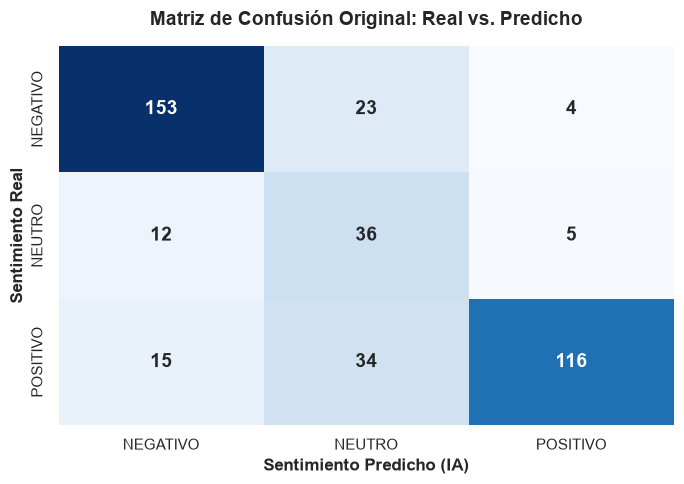

In [4]:
df_original = evaluar_modelo("Original", "modelo_original/", "clasificacion_resultado_original.csv", "modelo_original.png")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Resultado Entrenado: 326 aciertos de 398 (81.9%)

Reporte de Métricas Entrenado:
              precision    recall  f1-score   support

    NEGATIVO       0.93      0.86      0.89       180
      NEUTRO       0.44      0.70      0.54        53
    POSITIVO       0.91      0.82      0.86       165

    accuracy                           0.82       398
   macro avg       0.76      0.79      0.76       398
weighted avg       0.86      0.82      0.83       398



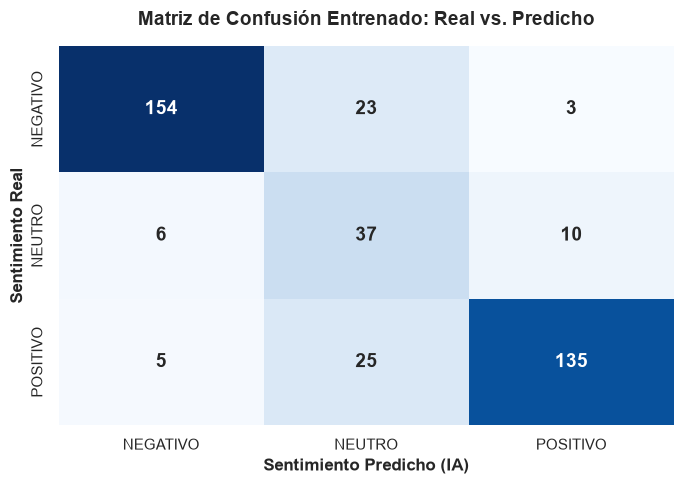

In [5]:
df_entrenado = evaluar_modelo("Entrenado", "mejor_modelo/", "clasificacion_resultado_entrenado.csv", "modelo_entrenado.png")

Precisión Original: 76.63%
Precisión Entrenado: 81.91%
Mejora absoluta: +5.28 puntos porcentuales
Mejora relativa: +6.89%


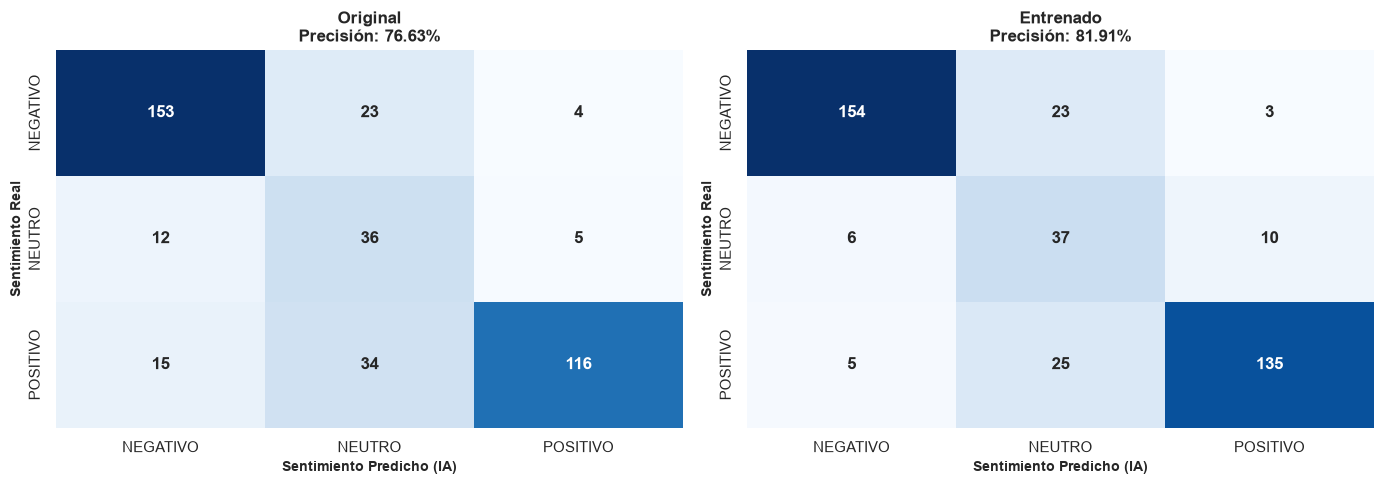

In [6]:
resultado_comparacion = comparar_modelos(df_original, df_entrenado, "Original", "Entrenado")